# Kernel PCA: Nonlinear Dimensionality Reduction

This notebook explores Kernel PCA — a nonlinear extension of PCA.

We will:

- Understand why linear PCA fails on curved manifolds
- Introduce the kernel trick
- Derive Kernel PCA formulation
- Apply RBF Kernel PCA
- Compare with Linear PCA
- Visualize nonlinear unfolding

## Motivation: When Linear PCA Fails

Linear PCA assumes data lies near a linear subspace.

However, many real-world datasets lie on nonlinear manifolds.

Example: Points arranged on a circle.

Although intrinsic dimension = 1,
linear projection distorts structure.

We demonstrate this below.

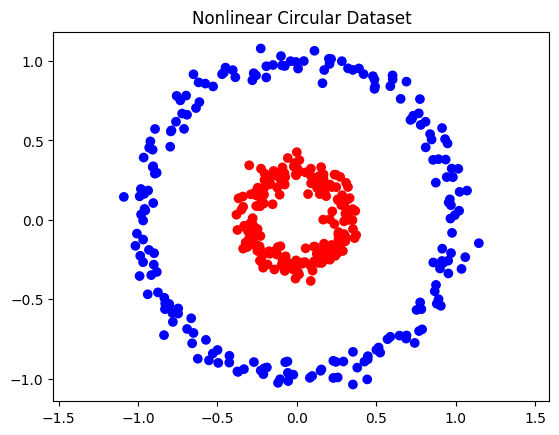

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

X, y = make_circles(n_samples=400, factor=0.3, noise=0.05, random_state=42)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap="bwr")
plt.title("Nonlinear Circular Dataset")
plt.axis("equal")
plt.show()

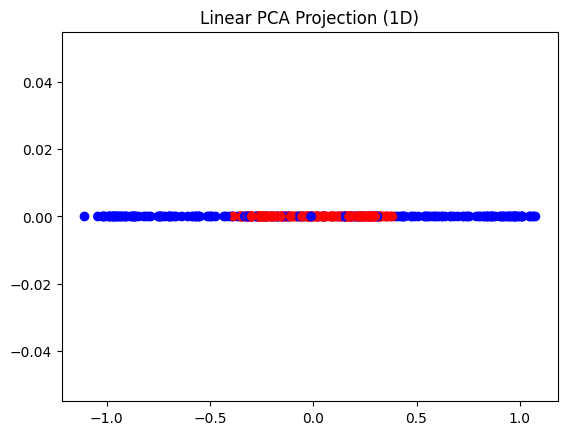

In [2]:
from sklearn.decomposition import PCA

pca = PCA(n_components=1)
X_linear_pca = pca.fit_transform(X)

plt.scatter(X_linear_pca, np.zeros_like(X_linear_pca), c=y, cmap="bwr")
plt.title("Linear PCA Projection (1D)")
plt.show()

### Observation

Linear PCA collapses the circle into overlapping points.

Points that were far apart on the circle become close after projection.

Linear PCA fails because the structure is nonlinear.

## Kernel PCA Theory

Instead of performing PCA on X directly,
we implicitly map data into a high-dimensional feature space:

ϕ : ℝᵈ → ℝᴰ

We perform linear PCA in feature space without computing ϕ explicitly.

Kernel trick:

Kᵢⱼ = k(xᵢ, xⱼ) = ⟨ϕ(xᵢ), ϕ(xⱼ)⟩

Kernel PCA solves eigenvalue problem:

K α = n λ α

Where:
- K is kernel matrix (n × n)
- α are eigenvectors in feature space
- λ are eigenvalues

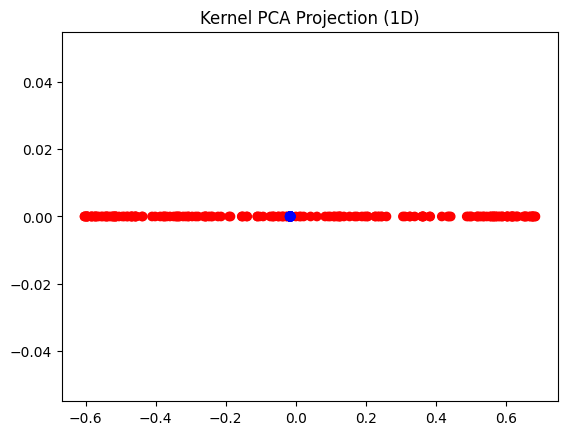

In [3]:
from sklearn.decomposition import KernelPCA

kpca = KernelPCA(
    n_components=1,
    kernel="rbf",
    gamma=15
)

X_kpca = kpca.fit_transform(X)

plt.scatter(X_kpca, np.zeros_like(X_kpca), c=y, cmap="bwr")
plt.title("Kernel PCA Projection (1D)")
plt.show()

### Observation

Kernel PCA successfully separates the circular structure into two distinct regions.

Unlike linear PCA, nonlinear geometry is preserved.

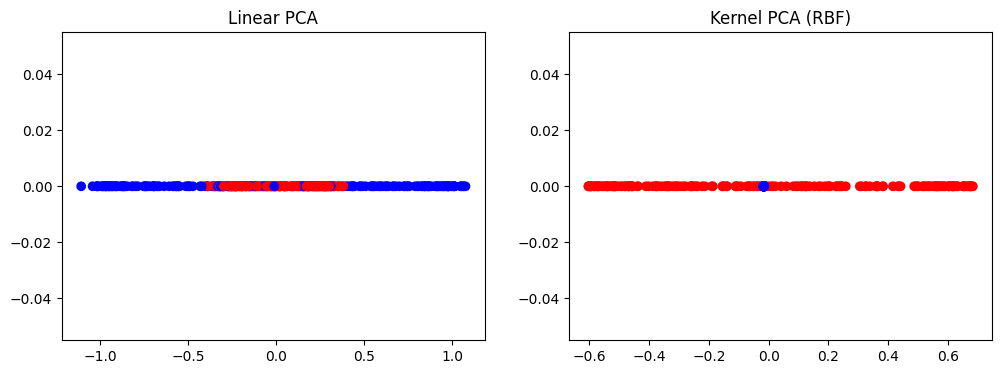

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].scatter(X_linear_pca, np.zeros_like(X_linear_pca), c=y, cmap="bwr")
ax[0].set_title("Linear PCA")

ax[1].scatter(X_kpca, np.zeros_like(X_kpca), c=y, cmap="bwr")
ax[1].set_title("Kernel PCA (RBF)")

plt.show()

## Geometric Interpretation

Linear PCA searches for best linear subspace.

Kernel PCA:

1. Maps data to high-dimensional feature space.
2. Linear PCA separates curved structure there.
3. Projection corresponds to nonlinear transformation in original space.

RBF kernel effectively measures similarity in radial distance,
allowing circular manifolds to unfold.

## Computational Considerations

Kernel matrix size: n × n

Memory cost: O(n²)  
Eigen-decomposition cost: O(n³)

Kernel PCA scales poorly with large datasets.

Linear PCA scales with number of features instead.

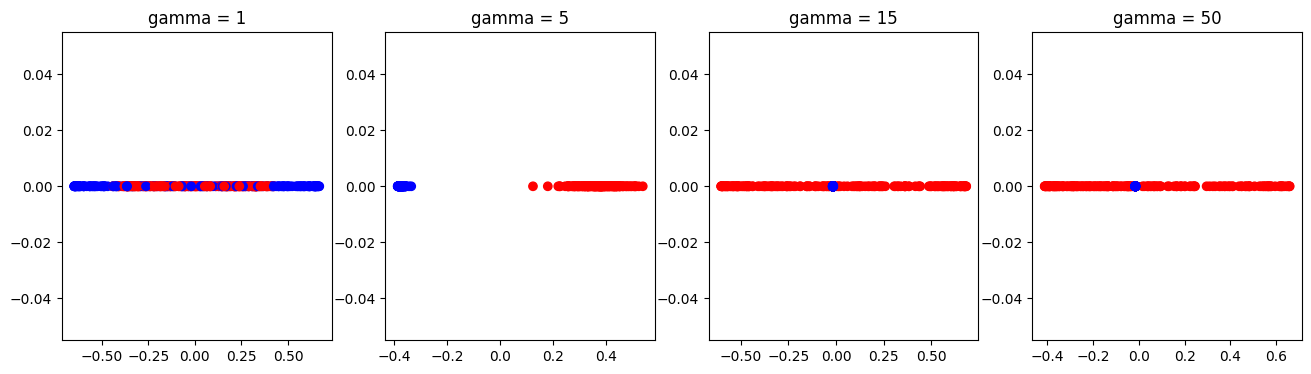

In [5]:
gammas = [1, 5, 15, 50]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for gamma, ax in zip(gammas, axes):
    kpca = KernelPCA(n_components=1, kernel="rbf", gamma=gamma)
    X_kpca = kpca.fit_transform(X)
    ax.scatter(X_kpca, np.zeros_like(X_kpca), c=y, cmap="bwr")
    ax.set_title(f"gamma = {gamma}")

plt.show()

### Effect of Gamma

Small gamma → smooth mapping  
Large gamma → overfitting to local structure  

Gamma controls locality of nonlinear transformation.

# Final Insights

• Kernel PCA enables nonlinear dimensionality reduction  
• Uses kernel trick to avoid explicit feature mapping  
• Effective for curved manifolds  
• Computational cost scales with number of samples  
• Hyperparameter gamma controls flexibility  

Kernel PCA is powerful but expensive.